In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/project_3/uber_cleaned.xlsx')

In [ ]:
df.head()

,Row_ID,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,...,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Datetime,Hour,DayOfWeek
0,0,2024-03-23,12:29:38,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,...,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,Saturday
1,1,2024-11-29,18:01:39,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,...,1,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39,18,Friday
2,2,2024-08-23,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,...,0,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,Friday
3,3,2024-10-21,17:17:25,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,...,0,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,17,Monday
4,4,2024-09-16,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,...,0,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,22,Monday


#A. Demand & Funnel Health


###1. What's the overall platform demand?

In [ ]:
total_bookings = df['Row_ID'].nunique()
total_bookings

150000

**1. Total Bookings 150,000**

**Insight:** Baseline demand volume for the study period (2024, full year).

**Recommendation:** No action required.

###2. Where is the booking funnel leaking?

In [ ]:
status_counts = df['Booking Status'].value_counts()
status_pct = df['Booking Status'].value_counts(normalize=True) * 100

completion_rate = (df['Booking Status'] == 'Completed').mean() * 100
cust_cancel_rate = df['Cancelled Rides by Customer'].sum() / total_bookings * 100
driver_cancel_rate = df['Cancelled Rides by Driver'].sum() / total_bookings * 100
incomplete_rate = df['Incomplete Rides'].sum() / total_bookings * 100

In [ ]:
# 1. Booking Status Counts (Absolute Numbers)
status_counts = df['Booking Status'].value_counts()
print("--- Booking Status Counts ---")
print(status_counts)
print()  # Adds a blank line for readability

# 2. Booking Status Percentages
status_pct = df['Booking Status'].value_counts(normalize=True) * 100
print("--- Booking Status Percentages (%) ---")
print(status_pct)
print()

# 3. Completion Rate
completion_rate = (df['Booking Status'] == 'Completed').mean() * 100
print(f"Ride Completion Rate: {completion_rate:.2f}%")

# 4. Customer Cancellation Rate
cust_cancel_rate = df['Cancelled Rides by Customer'].sum() / total_bookings * 100
print(f"Customer Cancellation Rate: {cust_cancel_rate:.2f}%")

# 5. Driver Cancellation Rate
driver_cancel_rate = df['Cancelled Rides by Driver'].sum() / total_bookings * 100
print(f"Driver Cancellation Rate: {driver_cancel_rate:.2f}%")

# 6. Incomplete Rides Rate
incomplete_rate = df['Incomplete Rides'].sum() / total_bookings * 100
print(f"Incomplete Rides Rate: {incomplete_rate:.2f}%")

--- Booking Status Counts ---
Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

--- Booking Status Percentages (%) ---
Booking Status
Completed                62.0
Cancelled by Driver      18.0
No Driver Found           7.0
Cancelled by Customer     7.0
Incomplete                6.0
Name: proportion, dtype: float64

Ride Completion Rate: 62.00%
Customer Cancellation Rate: 7.00%
Driver Cancellation Rate: 18.00%
Incomplete Rides Rate: 6.00%


**2. Booking Funnel, 62% Completion Rate**

**Insight:**

38% of demand is failing to convert into a completed ride. Of that, **Driver Cancellations (18%) are the single largest leak** , 2.6x larger than Customer Cancellations (7%) and 3x larger than No Driver Found (7%). Incomplete rides add another 6%.

**Recommendation:**

This is a **supply-side problem, not a demand-side problem**. Priority fix is driver-side: investigate driver cancellation reasons (once reason-code data is analyzed in Phase 6) and consider driver incentive/penalty rebalancing before spending on customer acquisition or marketing — acquiring more riders into a funnel that drops 38% of them wastes CAC.

#B. Revenue


###3. What revenue did completed rides generate?

In [ ]:
# Total Revenue
total_revenue = df.loc[df['Booking Status']=='Completed', 'Booking Value'].sum()
print(total_revenue)

47260574.0


### 4. What's the typical ride ticket size?

In [ ]:
#Average Booking Value
avg_booking_value = df.loc[df['Booking Status']=='Completed', 'Booking Value'].mean().round()
print(avg_booking_value)

508.0


### 5. How much revenue is at risk from failed bookings?

In [ ]:
#Revenue Lost
failed = df[df['Booking Status'] != 'Completed']
revenue_lost_proxy = len(failed) * avg_booking_value
print(revenue_lost_proxy)

28956000.0


**3–5. Revenue: ₹47.26M Actual, ₹28.96M At-Risk (Proxy)**

**Insight:**

Completed rides generated ₹47.26M at an average ticket size of ₹508. The 46,500 failed bookings represent an estimated ₹28.96M in unrealized revenue, equivalent to **~61% of actual revenue currently being left on the table**.


**Recommendation:**

 Even a 5-point improvement in completion rate (62%→67%) would recover roughly ₹3.8-4M annually at current avg ticket size. Fixing driver cancellations (KPI 2) is the highest-leverage revenue action available.

#C. Operational Efficiency

###6. How long do customers wait for a driver to arrive?

In [ ]:
#Average VTAT (Vehicle Turnaround/Arrival Time)
avg_vtat = df['Avg VTAT'].mean().round()
print(avg_vtat)

8.0


###7. How long does the actual trip take on average?

In [ ]:
#Average CTAT (Customer Turnaround/Trip Time)
avg_ctat = df['Avg CTAT'].mean().round()
print(avg_ctat)

29.0


###8. What's the typical trip length (fleet utilization indicator)?

In [ ]:
#Average Ride Distance
avg_distance = df.loc[df['Booking Status']=='Completed', 'Ride Distance'].mean().round()
print(avg_distance)

26.0


**6–8. Operational Efficiency, VTAT 8 min / CTAT 29 min / Avg Distance 26 km**

**Insight:** Driver arrival wait (8 min) is reasonable and not the bottleneck. Trip time (29 min) against 26 km average distance implies ~54 km/h average trip speed, acceptable for a mixed urban fleet, not a red flag on its own.

**Recommendation:** No immediate action; these are healthy operational baselines. Worth revisiting only if segmented by vehicle type or location shows outliers.

#D. Quality / Satisfaction


###9. Is service quality acceptable on both sides of the marketplace?

In [ ]:
#Average Driver Rating & Average Customer Rating

avg_driver_rating = df['Driver Ratings'].mean().round(2)
print(f"Average Driver Rating: ", avg_driver_rating)

avg_customer_rating = df['Customer Rating'].mean().round(2)
print(f"Average Customer Rating: ", avg_customer_rating)

Average Driver Rating:  4.23
Average Customer Rating:  4.4


**9. Service Quality, Driver Rating 4.23 / Customer Rating 4.4**

**Insight:** Both sides of the marketplace report healthy satisfaction.

**Recommendation:** No action required.

#E. Vehicle & Location Mix


###10. Which vehicle type drives the most completed rides/revenue?

In [ ]:
#Top Performing Vehicle

# 1. Top 5 Vehicle Types by Completed Bookings
top_vehicle_bookings = df[df['Booking Status']=='Completed']['Vehicle Type'].value_counts().head(5)
print("--- Top 5 Vehicle Types by Completed Bookings ---")
print(top_vehicle_bookings)
print()

# 2. Total Revenue by Vehicle Type (Sorted Highest to Lowest)
top_vehicle_revenue = df[df['Booking Status']=='Completed'].groupby('Vehicle Type')['Booking Value'].sum().sort_values(ascending=False)
print("--- Total Revenue by Vehicle Type (Completed Bookings) ---")
print(top_vehicle_revenue)

--- Top 5 Vehicle Types by Completed Bookings ---
Vehicle Type
Auto             23155
Go Mini          18549
Go Sedan         16676
Bike             14034
Premier Sedan    11252
Name: count, dtype: int64

--- Total Revenue by Vehicle Type (Completed Bookings) ---
Vehicle Type
Auto             11727615.0
Go Mini           9411418.0
Go Sedan          8538560.0
Bike              7144913.0
Premier Sedan     5733655.0
eBike             3298157.0
Uber XL           1406256.0
Name: Booking Value, dtype: float64


**10. Vehicle Mix — Auto Leads Bookings & Revenue**

**Insight:** Auto is the top performer on both volume (23,155 completed) and revenue (₹11.73M), followed by Go Mini and Go Sedan. Uber XL and eBike are the smallest contributors (₹1.4M and ₹3.3M).

**Recommendation:** Prioritize driver supply and fleet investment toward Auto/Go Mini/Go Sedan, which together drive ~62% of completed-ride revenue. Uber XL is a low-volume niche, don't over-invest in supply there.

###11. Where should Uber focus driver supply/marketing?

In [ ]:
#Top Pickup Location
top_pickup = df['Pickup Location'].value_counts().head(10)
print("--- Top Pickup Location ---")
print(top_pickup)

--- Top Pickup Location ---
Pickup Location
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
Madipur             919
AIIMS               918
Mehrauli            915
Dwarka Sector 21    914
Pataudi Chowk       907
Name: count, dtype: int64


**11. Location Hotspots, Fairly Even Top-10 Spread**

**Insight:** Top pickup locations (Khandsa, Barakhamba Road, Saket, etc.) are tightly clustered between 907–949 bookings, no single dominant hotspot, demand is broadly distributed across Delhi-NCR.

**Recommendation:** Driver supply/marketing should be distributed across this top-10 cluster rather than concentrated on one "hero" location, no single-point fix here.

#F. Trend


###12. Is revenue growing, flat, or declining over the period?

In [ ]:
#Monthly Revenue
daily_revenue = df[df['Booking Status']=='Completed'].groupby('Date')['Booking Value'].sum()
print(daily_revenue)

Date
2024-01-01    115250.0
2024-01-02    106568.0
2024-01-03    106740.0
2024-01-04    106500.0
2024-01-05    121177.0
                ...   
2024-12-26    114895.0
2024-12-27    128067.0
2024-12-28    169755.0
2024-12-29    200010.0
2024-12-30    109384.0
Name: Booking Value, Length: 365, dtype: float64


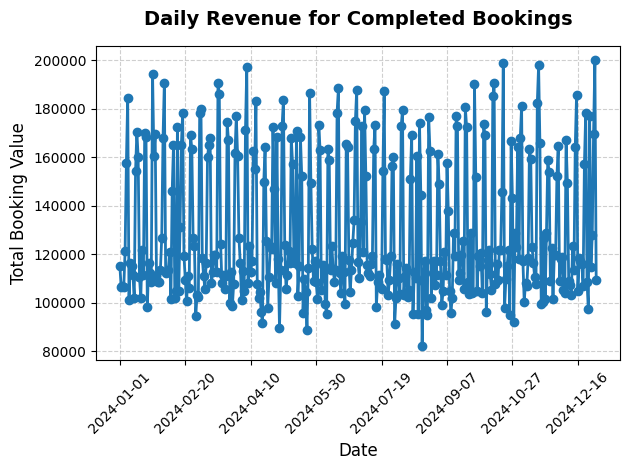

In [ ]:
import matplotlib.pyplot as plt


daily_revenue = daily_revenue.sort_index()

daily_revenue.plot(kind='line', marker='o', linewidth=2, color='#1f77b4')
plt.title('Daily Revenue for Completed Bookings', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Booking Value', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('daily_revenue_line_chart.png', dpi=300)


### 12. Daily Revenue Trend

**Insight:** Daily revenue remains largely **flat** throughout the period, with most values ranging between **₹100K–120K**. Frequent short-term spikes (up to ~₹200K) occur across the year, but there is no clear upward or downward trend in overall revenue.

**Recommendation:** Since revenue appears stable with periodic spikes, further analysis of seasonal events, promotions, or holidays is recommended to identify the drivers of peak revenue days.


---

## Overall Business Insight

Uber's Delhi-NCR operation processes 150K bookings/year generating ₹47.26M, but is **losing more potential revenue (₹28.96M) than a 5-10 point funnel fix would take to recover** because the primary failure mode is **driver-side cancellation (18%)**, not customer demand or vehicle mix. Operational metrics (wait time, trip time) and satisfaction scores (4.23/4.4) are healthy, meaning the platform's core service quality isn't the problem, **driver retention/incentive at the point of match is**. The single highest-ROI intervention is reducing driver cancellations, which would simultaneously lift completion rate, recover revenue, and likely close the driver-vs-customer rating gap.